In [ ]:
import os

for root, dirs, files in os.walk('/'):
    for file in files:
        if 'cancer' in file.lower() and file.lower().endswith('.zip'):
            print(os.path.join(root, file))

/cancer issue.zip


In [ ]:
import zipfile
import os

with zipfile.ZipFile('/cancer issue.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/cancer_issue')

print(os.listdir('/content/cancer_issue'))

['cancer issue.csv']


In [ ]:
import pandas as pd

df = pd.read_csv('/content/cancer_issue/cancer issue.csv')
df.head()

,PatientID,Age,Gender,Race/Ethnicity,BMI,SmokingStatus,FamilyHistory,CancerType,Stage,TumorSize,TreatmentType,TreatmentResponse,SurvivalMonths,Recurrence,GeneticMarker,HospitalRegion
0,1,80,Female,Other,23.3,Smoker,Yes,Breast,II,1.7,Combination Therapy,No Response,103,Yes,NaN,South
1,2,76,Male,Caucasian,22.4,Former Smoker,Yes,Colon,IV,4.7,Surgery,No Response,14,Yes,BRCA1,West
2,3,69,Male,Asian,21.5,Smoker,Yes,Breast,III,8.3,Combination Therapy,Complete Remission,61,Yes,BRCA1,West
3,4,77,Male,Asian,30.4,Former Smoker,Yes,Prostate,II,1.7,Radiation,Partial Remission,64,No,KRAS,South
4,5,89,Male,Caucasian,20.9,Smoker,Yes,Lung,IV,7.4,Radiation,No Response,82,Yes,KRAS,South


In [ ]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install networkx scikit-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.2 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [ ]:
print(df.shape)
print(df.columns.tolist())
df.info()

(17686, 16)
['PatientID', 'Age', 'Gender', 'Race/Ethnicity', 'BMI', 'SmokingStatus', 'FamilyHistory', 'CancerType', 'Stage', 'TumorSize', 'TreatmentType', 'TreatmentResponse', 'SurvivalMonths', 'Recurrence', 'GeneticMarker', 'HospitalRegion']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17686 entries, 0 to 17685
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          17686 non-null  int64  
 1   Age                17686 non-null  int64  
 2   Gender             17686 non-null  object 
 3   Race/Ethnicity     17686 non-null  object 
 4   BMI                17686 non-null  float64
 5   SmokingStatus      17686 non-null  object 
 6   FamilyHistory      17686 non-null  object 
 7   CancerType         17686 non-null  object 
 8   Stage              17686 non-null  object 
 9   TumorSize          17686 non-null  float64
 10  TreatmentType      17686 non-null  object 
 11  TreatmentResponse  

In [ ]:
target_col = 'Stage'

In [ ]:
target_col = 'Stage'
drop_cols = ['PatientID']

In [ ]:
X = df.drop(columns=[target_col] + drop_cols, errors='ignore')
y = df[target_col].copy()

print("Ukuran fitur:", X.shape)
print("Ukuran target:", y.shape)
print("Distribusi target:")
print(y.value_counts())

Ukuran fitur: (17686, 14)
Ukuran target: (17686,)
Distribusi target:
Stage
I      4471
II     4442
III    4435
IV     4338
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# target dan kolom buang
target_col = 'Stage'
drop_cols = ['PatientID']

# pisah fitur dan target
X = df.drop(columns=[target_col] + drop_cols, errors='ignore').copy()
y = df[target_col].copy()

print("Sebelum encoding:")
print(X.dtypes)

# encode semua kolom kategorikal di X
label_encoders = {}

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].astype(str)
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le

# encode target
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y.astype(str))

print("\nSesudah encoding:")
print(X.dtypes)
print("\nKelas target:", target_encoder.classes_)

# imputasi missing value
imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X)

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

X_scaled = np.array(X_scaled, dtype=np.float32)
y_encoded = np.array(y_encoded, dtype=np.int64)

print("\nShape akhir:")
print("X_scaled:", X_scaled.shape)
print("y_encoded:", y_encoded.shape)

Sebelum encoding:
Age                    int64
Gender                object
Race/Ethnicity        object
BMI                  float64
SmokingStatus         object
FamilyHistory         object
CancerType            object
TumorSize            float64
TreatmentType         object
TreatmentResponse     object
SurvivalMonths         int64
Recurrence            object
GeneticMarker         object
HospitalRegion        object
dtype: object

Sesudah encoding:
Age                    int64
Gender                 int64
Race/Ethnicity         int64
BMI                  float64
SmokingStatus          int64
FamilyHistory          int64
CancerType             int64
TumorSize            float64
TreatmentType          int64
TreatmentResponse      int64
SurvivalMonths         int64
Recurrence             int64
GeneticMarker          int64
HospitalRegion         int64
dtype: object

Kelas target: ['I' 'II' 'III' 'IV']

Shape akhir:
X_scaled: (17686, 14)
y_encoded: (17686,)


In [ ]:
from sklearn.neighbors import kneighbors_graph

k = 5
A = kneighbors_graph(X_scaled, n_neighbors=k, mode='connectivity', include_self=False)

rows, cols = A.nonzero()
edges = list(zip(rows, cols))

print("Jumlah edges:", len(edges))
print("Contoh edges:", edges[:10])

Jumlah edges: 88430
Contoh edges: [(np.int32(0), np.int32(2336)), (np.int32(0), np.int32(2221)), (np.int32(0), np.int32(10967)), (np.int32(0), np.int32(5815)), (np.int32(0), np.int32(9714)), (np.int32(1), np.int32(1540)), (np.int32(1), np.int32(16247)), (np.int32(1), np.int32(5769)), (np.int32(1), np.int32(17219)), (np.int32(1), np.int32(5199))]


In [ ]:
import torch
from torch_geometric.data import Data

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
x_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
print(data)

Data(x=[17686, 14], edge_index=[2, 88430], y=[17686])


In [ ]:
from sklearn.neighbors import kneighbors_graph

k = 5
A = kneighbors_graph(X_scaled, n_neighbors=k, mode='connectivity', include_self=False)

rows, cols = A.nonzero()
edges = list(zip(rows, cols))

print("Jumlah node:", X_scaled.shape[0])
print("Jumlah edge:", len(edges))
print("Contoh edge:", edges[:10])

Jumlah node: 17686
Jumlah edge: 88430
Contoh edge: [(np.int32(0), np.int32(2336)), (np.int32(0), np.int32(2221)), (np.int32(0), np.int32(10967)), (np.int32(0), np.int32(5815)), (np.int32(0), np.int32(9714)), (np.int32(1), np.int32(1540)), (np.int32(1), np.int32(16247)), (np.int32(1), np.int32(5769)), (np.int32(1), np.int32(17219)), (np.int32(1), np.int32(5199))]


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(range(len(X_scaled)))
G.add_edges_from(edges)

print("Jumlah node graph:", G.number_of_nodes())
print("Jumlah edge graph:", G.number_of_edges())

Jumlah node graph: 17686
Jumlah edge graph: 58494


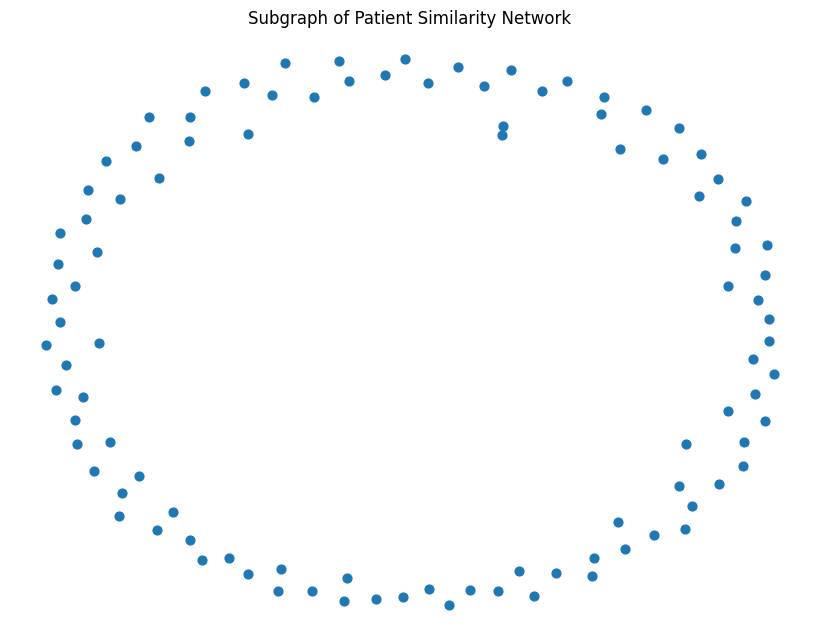

In [ ]:
plt.figure(figsize=(8, 6))
sub_nodes = list(range(100))
subG = G.subgraph(sub_nodes)
pos = nx.spring_layout(subG, seed=42)
nx.draw(subG, pos, node_size=40, with_labels=False)
plt.title("Subgraph of Patient Similarity Network")
plt.show()

In [ ]:
import torch
from torch_geometric.data import Data

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

x_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
print(data)

Data(x=[17686, 14], edge_index=[2, 88430], y=[17686])


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

num_nodes = len(X_scaled)
indices = np.arange(num_nodes)

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.test_mask = test_mask

print("Train nodes:", train_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

Train nodes: 14148
Test nodes: 3538


In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

model = GCN(
    in_channels=data.num_features,
    hidden_channels=32,
    out_channels=len(np.unique(y_encoded))
).to(device)

data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

Device: cpu


In [ ]:
train_losses = []
test_accuracies = []

for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()

    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)
        test_acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item()

    train_losses.append(loss.item())
    test_accuracies.append(test_acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Test Acc: {test_acc:.4f}")

Epoch 010 | Loss: 1.4204 | Test Acc: 0.2549
Epoch 020 | Loss: 1.3971 | Test Acc: 0.2510
Epoch 030 | Loss: 1.3872 | Test Acc: 0.2634
Epoch 040 | Loss: 1.3839 | Test Acc: 0.2674
Epoch 050 | Loss: 1.3817 | Test Acc: 0.2651
Epoch 060 | Loss: 1.3799 | Test Acc: 0.2719
Epoch 070 | Loss: 1.3790 | Test Acc: 0.2674
Epoch 080 | Loss: 1.3780 | Test Acc: 0.2626
Epoch 090 | Loss: 1.3789 | Test Acc: 0.2620
Epoch 100 | Loss: 1.3773 | Test Acc: 0.2606


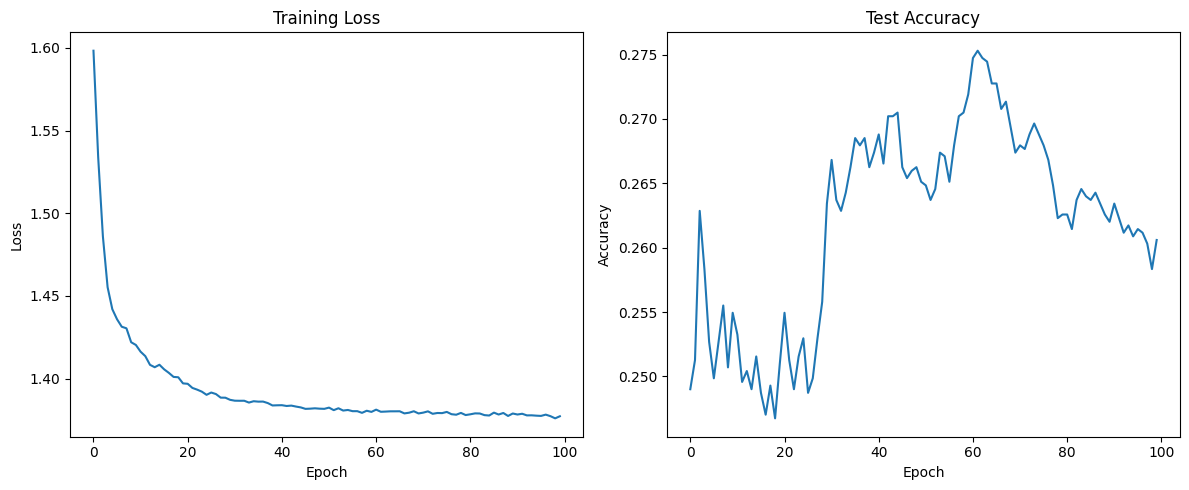

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(test_accuracies)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

model.eval()
with torch.no_grad():
    logits = model(data)
    y_pred = logits.argmax(dim=1).cpu().numpy()
    y_true = data.y.cpu().numpy()

test_true = y_true[data.test_mask.cpu().numpy()]
test_pred = y_pred[data.test_mask.cpu().numpy()]

print("Accuracy:", accuracy_score(test_true, test_pred))
print("F1-score (weighted):", f1_score(test_true, test_pred, average='weighted'))
print("\nClassification Report:")
print(classification_report(test_true, test_pred, target_names=target_encoder.classes_))

Accuracy: 0.2605992085924251
F1-score (weighted): 0.2576698388555465

Classification Report:
              precision    recall  f1-score   support

           I       0.26      0.29      0.27       894
          II       0.26      0.26      0.26       889
         III       0.27      0.32      0.29       887
          IV       0.25      0.17      0.20       868

    accuracy                           0.26      3538
   macro avg       0.26      0.26      0.26      3538
weighted avg       0.26      0.26      0.26      3538



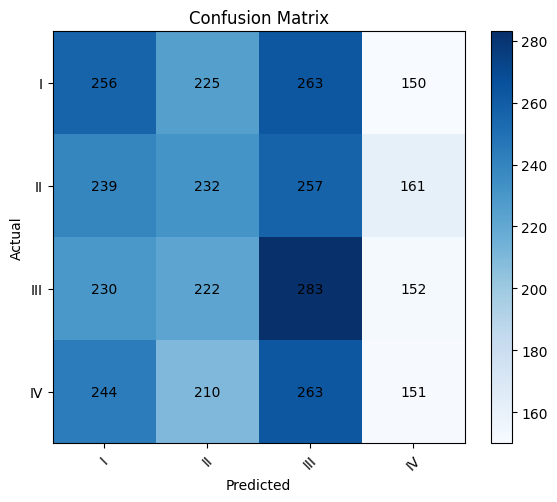

In [ ]:
cm = confusion_matrix(test_true, test_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(target_encoder.classes_)), target_encoder.classes_, rotation=45)
plt.yticks(range(len(target_encoder.classes_)), target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

In [ ]:
result_df = pd.DataFrame({
    'Actual': target_encoder.inverse_transform(test_true),
    'Predicted': target_encoder.inverse_transform(test_pred)
})

result_df.head()

,Actual,Predicted
0,IV,IV
1,II,II
2,III,II
3,II,III
4,I,II


In [ ]:
type(result_df)

pandas.core.frame.DataFrame

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'cancer_issue', 'sample_data']


In [ ]:
result_df.to_csv('/content/gnn_predictions_stage.csv', index=False)
print("saved")

saved


In [ ]:
import os
os.listdir('/content')

['.config', 'cancer_issue', 'gnn_predictions_stage.csv', 'sample_data']

In [ ]:
from google.colab import files
files.download('/content/gnn_predictions_stage.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
torch.save(model.state_dict(), '/content/gcn_stage_model.pth')
print("Model saved")

Model saved


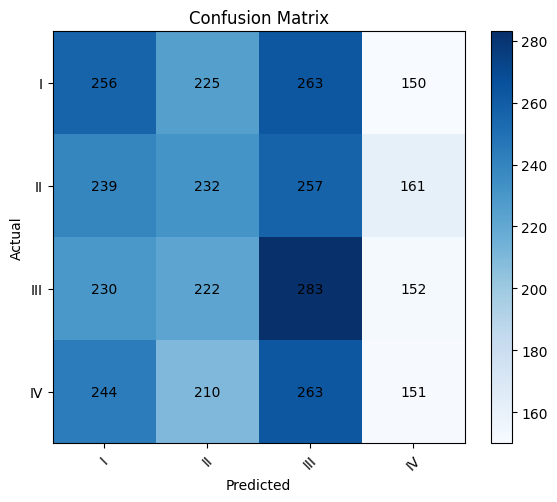

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(target_encoder.classes_)), target_encoder.classes_, rotation=45)
plt.yticks(range(len(target_encoder.classes_)), target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.savefig('/content/confusion_matrix_stage.png', dpi=300, bbox_inches='tight')
plt.show()

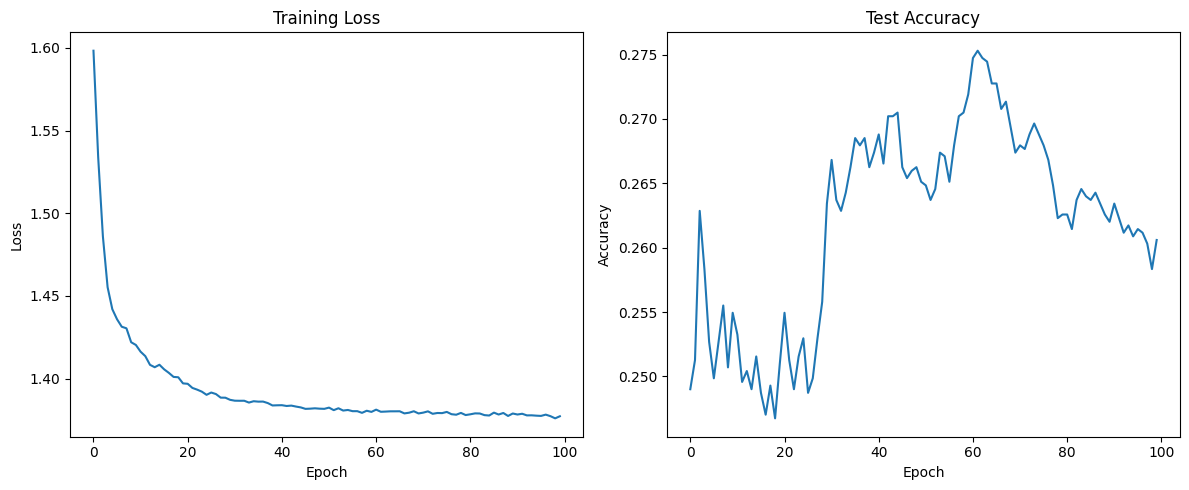

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(test_accuracies)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.savefig('/content/training_curve_stage.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
acc = accuracy_score(test_true, test_pred)
f1 = f1_score(test_true, test_pred, average='weighted')

print("Accuracy:", round(acc, 4))
print("Weighted F1-score:", round(f1, 4))

Accuracy: 0.2606
Weighted F1-score: 0.2577


In [ ]:
summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Weighted F1-score"],
    "Value": [acc, f1]
})

summary_df

,Metric,Value
0,Accuracy,0.260599
1,Weighted F1-score,0.257670


In [ ]:
summary_df.to_csv('/content/model_summary_stage.csv', index=False)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

X_train = X_scaled[train_idx]
X_test = X_scaled[test_idx]
y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("RF Weighted F1:", f1_score(y_test, rf_pred, average='weighted'))

RF Accuracy: 0.24279253815715093
RF Weighted F1: 0.24271899463725638


In [ ]:
from google.colab import files
files.download('/content/model_summary_stage.csv')
files.download('/content/confusion_matrix_stage.png')
files.download('/content/training_curve_stage.png')
files.download('/content/gcn_stage_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>